Cell 1 — Imports and Dataset

In [5]:
# Cell 0: All imports + NLTK downloads
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download NLTK data - run once
nltk.download('punkt')
nltk.download('punkt_tab')  # add this
nltk.download('stopwords') 
nltk.download('wordnet')

print("Imports + NLTK downloads done.")
# Cell 1: Load AG News
print("Loading train data...")
train_df = pd.read_csv("https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv",
                       header=None, names=['label', 'title', 'description'])
train_df['label'] = train_df['label'] - 1
train_df['text'] = train_df['title'] + " " + train_df['description']
train_df = train_df[['text','label']]

print("Loading test data...")
test_df = pd.read_csv("https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv",
                      header=None, names=['label', 'title', 'description'])
test_df['label'] = test_df['label'] - 1
test_df['text'] = test_df['title'] + " " + test_df['description']
test_df = test_df[['text','label']]

print(f"Train: {len(train_df)}, Test: {len(test_df)}")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dines\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dines\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dines\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dines\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Imports + NLTK downloads done.
Loading train data...
Loading test data...
Train: 120000, Test: 7600


Cell 2 — Create Preprocessor

In [6]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    
    text = text.lower()
    
    text = re.sub(r"http\S+", "", text)
    
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    tokens = word_tokenize(text)
    
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    
    return " ".join(tokens)

Cell 3 — Test On One Example

In [7]:
sample_text = train_df.iloc[0]["text"]

print("ORIGINAL:")
print(sample_text)

print("\nCLEANED:")
print(preprocess_text(sample_text))

ORIGINAL:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

CLEANED:
wall bear claw back black reuters reuters short seller wall street dwindling band ultra cynic seeing green


What happened:

Lowercased ✅
Punctuation removed ✅
Stopwords removed ✅
Lemmatized (bears → bear, sellers → seller) ✅
URLs/numbers handling ready ✅

This is suitable for:

TF-IDF
Logistic Regression
LDA Topic Modeling

Cell 4- CLEAN THE ENTIRE DATASET

In [8]:
print("Cleaning training data...")

train_df["clean_text"] = train_df["text"].apply(preprocess_text)

print("Cleaning test data...")

test_df["clean_text"] = test_df["text"].apply(preprocess_text)

print("Done.")

Cleaning training data...
Cleaning test data...
Done.


Cell 5 — INSPECT RESULTS

In [9]:
train_df[["text", "clean_text"]].head()

,text,clean_text
0,Wall St. Bears Claw Back Into the Black (Reute...,wall bear claw back black reuters reuters shor...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle look toward commercial aerospace reute...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil economy cloud stock outlook reuters reuter...
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halt oil export main southern pipeline re...
4,"Oil prices soar to all-time record, posing new...",oil price soar time record posing new menace e...


Cell 6 — CHECK FOR EMPTY DOCUMENTS

In [10]:
empty_train = (train_df["clean_text"].str.len() == 0).sum()
empty_test = (test_df["clean_text"].str.len() == 0).sum()

print("Empty train documents:", empty_train)
print("Empty test documents:", empty_test)

Empty train documents: 0
Empty test documents: 0


Cell 7- TF-IDF FEATURE EXTRACTION

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

Cell 8 — Create TF-IDF Features

In [12]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5
)

X_train = tfidf.fit_transform(train_df["clean_text"])
X_test = tfidf.transform(test_df["clean_text"])

y_train = train_df["label"]
y_test = test_df["label"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (120000, 10000)
X_test shape: (7600, 10000)


Cell 9 — LOGISTIC REGRESSION BASELINE

In [13]:
from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

print("Training complete.")

Training Logistic Regression...
Training complete.


Cell 10 — PREDICTIONS

In [14]:
y_pred = lr_model.predict(X_test)

print("Predictions generated.")

Predictions generated.


Cell 11 — EVALUATION

In [15]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "World",
        "Sports",
        "Business",
        "Sci/Tech"
    ]
))

Accuracy: 0.9087

Classification Report:

              precision    recall  f1-score   support

       World       0.93      0.90      0.91      1900
      Sports       0.95      0.98      0.96      1900
    Business       0.87      0.87      0.87      1900
    Sci/Tech       0.88      0.88      0.88      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



Cell 12- CONFUSION MATRIX

Confusion Matrix:
[[1715   58   83   44]
 [  21 1858   11   10]
 [  62   20 1653  165]
 [  53   22  145 1680]]

Confusion Matrix with Labels:
          World  Sports  Business  Sci/Tech
World      1715      58        83        44
Sports       21    1858        11        10
Business     62      20      1653       165
Sci/Tech     53      22       145      1680


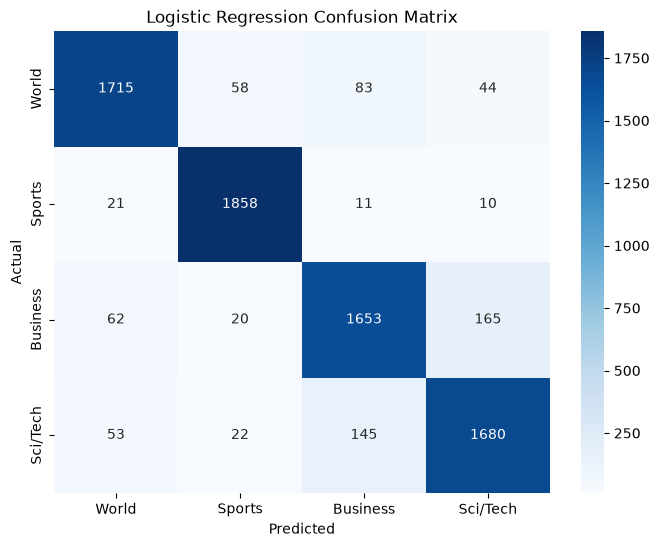

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

# 1. Print matrix in terminal
print("Confusion Matrix:")
print(cm)

# 2. Print with labels for readability
print("\nConfusion Matrix with Labels:")
labels = ["World","Sports","Business","Sci/Tech"]
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
print(cm_df)

# 3. Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Logistic Regression Results

Accuracy: 90.87%

Observations:

- Sports achieved the highest F1-score (0.96).
- Business and Sci/Tech were the most commonly confused classes.
- The model performed consistently across all four categories.
- Overall accuracy exceeded 90%, demonstrating the effectiveness of TF-IDF features combined with Logistic Regression.

Cell 13- TRAIN SVM

In [17]:
from sklearn.svm import LinearSVC

print("Training Linear SVM...")

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train, y_train)

print("Training complete.")

Training Linear SVM...
Training complete.


Cell 14- Predict

In [18]:
svm_pred = svm_model.predict(X_test)

Cell 15- Evaluate

In [19]:
from sklearn.metrics import accuracy_score, classification_report

svm_accuracy = accuracy_score(y_test, svm_pred)

print(f"SVM Accuracy: {svm_accuracy:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        svm_pred,
        target_names=[
            "World",
            "Sports",
            "Business",
            "Sci/Tech"
        ]
    )
)

SVM Accuracy: 0.9116

Classification Report:

              precision    recall  f1-score   support

       World       0.93      0.91      0.92      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.88      0.87      0.87      1900
    Sci/Tech       0.89      0.89      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



## Model Comparison

We compare two classical machine learning models using TF-IDF features:

- Logistic Regression
- Linear SVM

### Results:
- Logistic Regression Accuracy: 90.87%
- Linear SVM Accuracy: 91.16%

### Observation:
Linear SVM performs slightly better, likely due to its effectiveness in high-dimensional sparse feature spaces typical of TF-IDF representations. However, both models show similar behavior, indicating that feature representation plays a more important role than model selection in this task.

In [20]:
# Cell FINAL: Save cleaned data for SBERT notebook
train_df.to_csv('train_clean.csv', index=False)
test_df.to_csv('test_clean.csv', index=False)

print("Saved:")
print("train_clean.csv - shape:", train_df.shape)
print("test_clean.csv - shape:", test_df.shape)
print("\nColumns saved:", train_df.columns.tolist())

Saved:
train_clean.csv - shape: (120000, 3)
test_clean.csv - shape: (7600, 3)

Columns saved: ['text', 'label', 'clean_text']
